# Perceptron from scratch in numpy

These code and images are from Chapter 2 and 3 in Raschka. (To retain the images do not execute the image code blocks!)

![alt text](MV5BYTgxMGZkZDktZTA3NS00Mjc1LTg3NDgtM2U4ZWU5NWEzNjE3XkEyXkFqcGc@.webp)

<br>
<br>

## The formal definition of an artificial neuron

In [66]:
#Image(filename='./figures/02_02.png', width=500) 

## The perceptron learning rule

In [67]:
#Image(filename='./figures/02_03.png', width=600) 

In [68]:
 #Image(filename='./figures/02_04.png', width=600) 

<br>
<br>

# Object-oriented APIs

The goals are 

-  Understand and apply Python code for these class definitions.
-  How perceptrons and adaline work; connect the code with the mathematics
-  How loss and gradient descent work in the context of ml models.
-  Fit these simple models to familiar data sets and experiment
-  Later, we will adapt perceptron to obtain linear and logistic regression with gradient descent

## Perceptron classifier

For a perceptron, the "loss function" is simply the error, though it is typically not referred to as that. The perceptron takes the samples one at a time and adjusts the weights and bias each time. It goes through all the samples and then repeats for however many epochs you specify.

In [ ]:
import numpy as np


class Perceptron:
    """Perceptron classifier.

    Parameters
    ------------
    eta : float
      Learning rate (between 0.0 and 1.0)
    n_iter : int
      Passes over the training dataset.
    random_state : int
      Random number generator seed for random weight
      initialization.

    Attributes
    -----------
    w_ : 1d-array
      Weights after fitting.
    b_ : Scalar
      Bias unit after fitting.
    errors_ : list
      Number of misclassifications (updates) in each epoch.

    """
    def __init__(self, eta, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        """Fit training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_examples, n_features]
          Training vectors, where n_examples is the number of examples and
          n_features is the number of features.
        y : array-like, shape = [n_examples]
          Target values.

        Returns
        -------
        self : object

        """
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.float_(0.)
        
        self.errors_ = []

        for _ in range(self.n_iter):     ## loop over epochs
            errors = 0
            for xi, target in zip(X, y):    ## loop over each sample, adjusting weights and bias
                update = self.eta * (target - self.predict(xi))
                self.w_ += update * xi
                self.b_ += update
                errors += int(update != 0.0)  ## if the update is zero, the sample is correctly classified; counts how many are not
            self.errors_.append(errors)
        return self

    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_) + self.b_   

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.net_input(X) >= 0.0, 1, 0)

The following plot assumes you have fit a model called `ppn` on some data. Try it! **Note:** If your data is stored as a data frame you may need to extract the data matrix values as an array using `.values` attribute,

In [70]:
import matplotlib.pyplot as plt
plt.plot(range(1, len(ppn.errors_) + 1), ppn.errors_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Number of updates')

# plt.savefig('images/02_07.png', dpi=300)
plt.show()

AttributeError: 'Perceptron' object has no attribute 'errors_'

## Adaptive linear neurons

Adaline replaces the error from the perceptron with mean square error.

## Minimizing loss functions with gradient descent

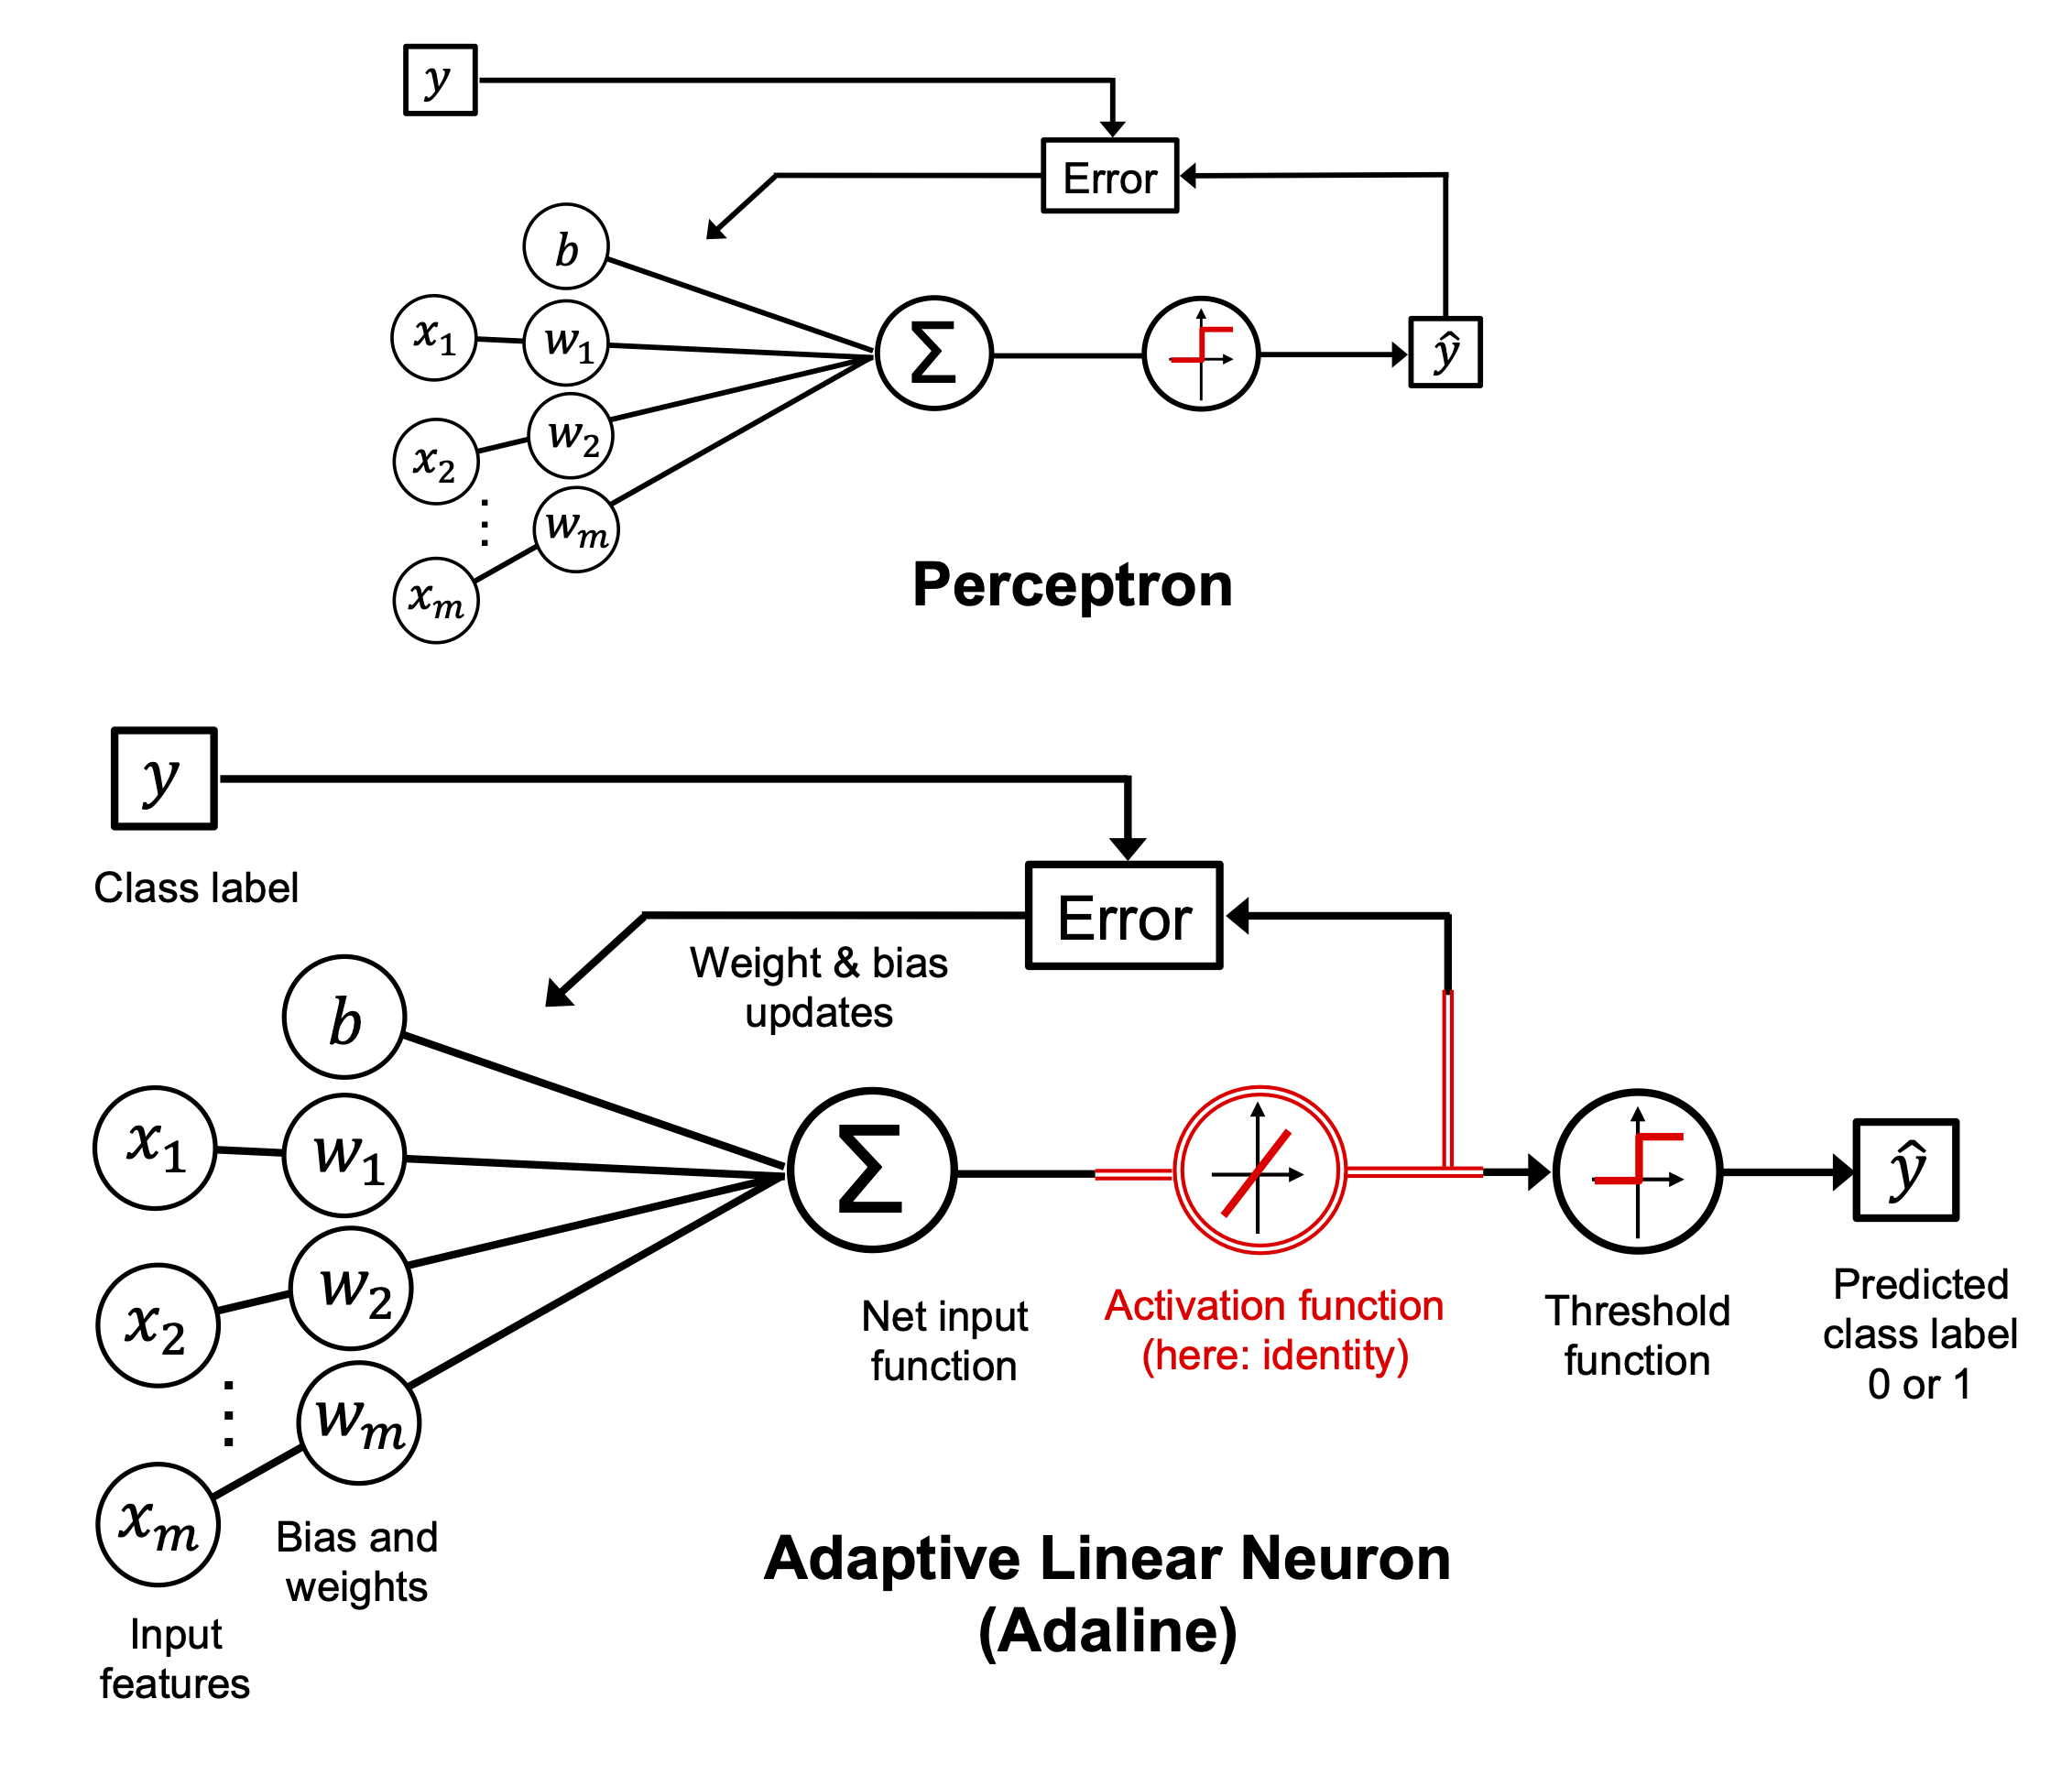

In [ ]:
 Image(filename='./figures/02_09.png', width=600) 

To fit the Adaline model, we will use gradient descent, which is a very broad class of optimization schemes used widely in machine learning, deep learning, and elsewhere. But first will need some calculus! 

Exercise:
Try your Adaline classifier on some binary classification data (for example the penguins data with species == Gentoo).
Plot the loss vs epoch
Find the accuracy

<br>
<br>

In [ ]:
import pandas as pd
import numpy as np
penguins = pd.read_csv('../data/penguins.csv')

penguins.head()

,...1,species,island,year,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,above_average_weight,sex
0,1,Adelie,Torgersen,2007,39.1,18.7,181,3750,0,male
1,2,Adelie,Torgersen,2007,39.5,17.4,186,3800,0,female
2,3,Adelie,Torgersen,2007,40.3,18.0,195,3250,0,female
3,5,Adelie,Torgersen,2007,36.7,19.3,193,3450,0,female
4,6,Adelie,Torgersen,2007,39.3,20.6,190,3650,0,male


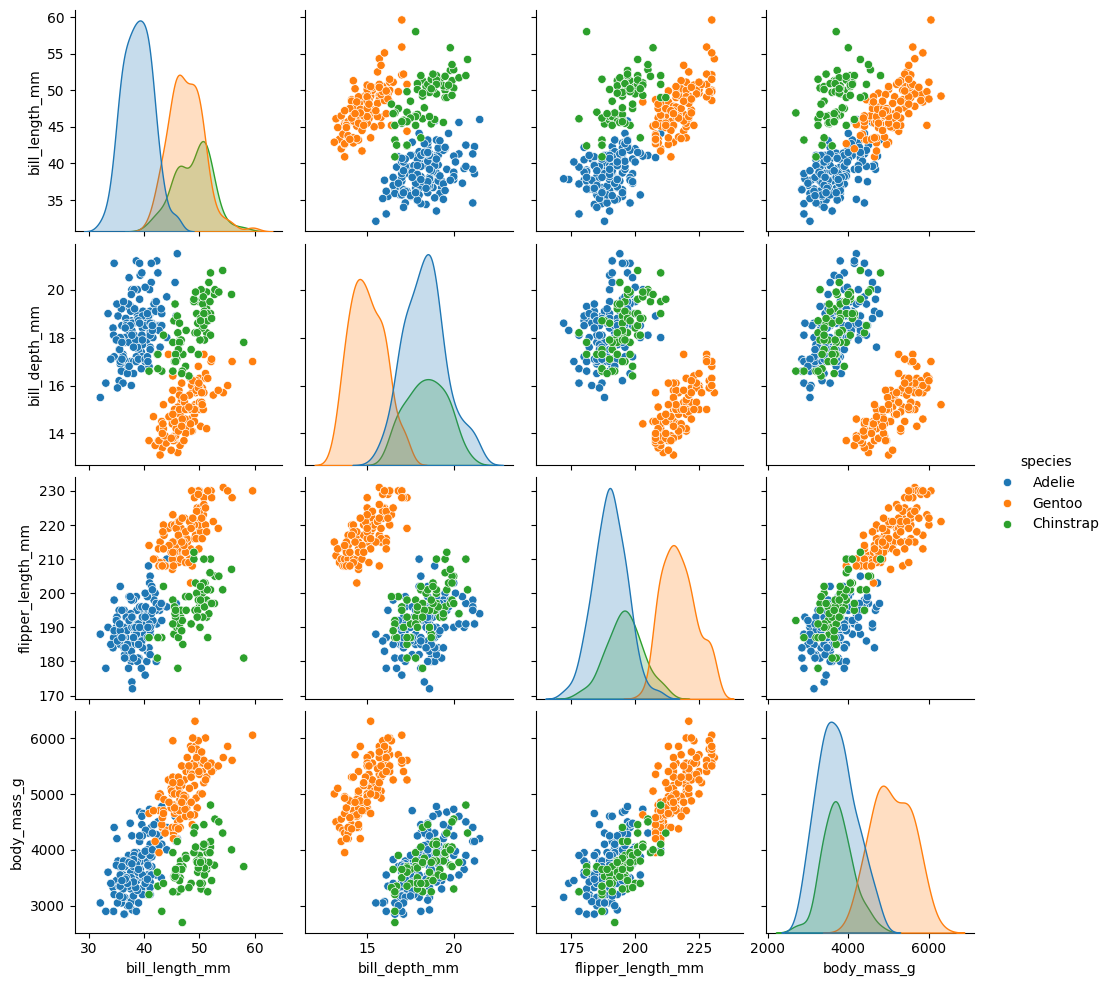

In [ ]:
import seaborn as sns
grid = sns.pairplot(data=penguins, vars= ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'], hue='species')

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

def fit_perceptron(X, y, eta, iter=20):
    """
    Trains a Perceptron classifier on input data.
    
    Parameters:
    - X: Predictor data matrix (n_samples, n_features)
    - y: Target binary array (0 or 1)
    - eta: Learning rate (default = 0.1)
    - iter: Number of epochs (default = 20)
    
    Returns:
    - yhat: Predicted class vector (0 or 1) for each observation
    - w: Weight vector including the bias (bias absorbed into index 0)
    - errors_list: Number of misclassifications per epoch
    """
    X = np.asarray(X)
    y = np.asarray(y)
    
    n_samples, n_features = X.shape
    
    # Absorb bias into w by adding a column of 1s to the left of X
    X_b = np.c_[np.ones(n_samples), X]
    
    # Initialize weights to zeros (length = n_features + 1 for bias)
    w = np.zeros(X_b.shape[1])
    
    errors_list = []
    
    for _ in range(iter):
        errors = 0
        for xi, target in zip(X_b, y):
            # Calculate unit step activation: 1 if z >= 0 else 0
            net_input = np.dot(xi, w)
            prediction = np.where(net_input >= 0.0, 1, 0)
            
            # Weight update rule
            update = eta * (target - prediction)
            w += update * xi
            
            # Record misclassification count
            errors += int(update != 0.0)
            
        errors_list.append(errors)
        
    # Generate final class predictions using trained weights
    net_inputs = np.dot(X_b, w)
    yhat = np.where(net_inputs >= 0.0, 1, 0)
    
    return yhat, w, errors_list

Learned Weights (w[0]=bias, w[1:]=features):
[-0.3         0.16076288 -0.17319057  0.17078532  0.12701041]

Final Classification Accuracy: 100.00%


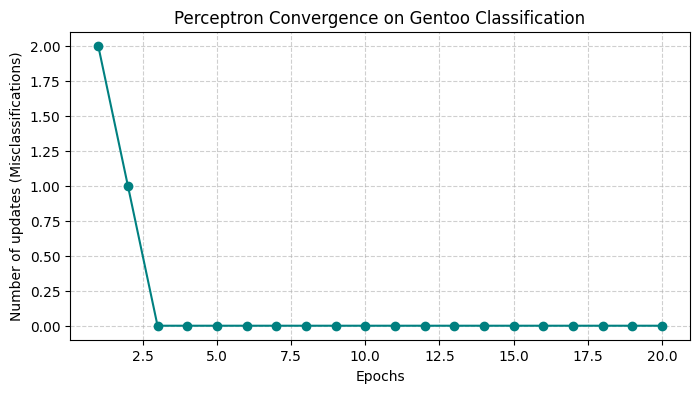

In [ ]:
# 1. Load dataset
penguins = pd.read_csv('../data/penguins.csv')

# 2. Define 0/1 column indicating Gentoo
penguins['isgentoo'] = (penguins['species'] == 'Gentoo').astype(int)

# 3. Predictor columns and target
predictor_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Clean missing values across predictor and target columns
clean_df = penguins.dropna(subset=predictor_cols + ['isgentoo'])

# Strip off unused columns to keep only predictors and target
data = clean_df[predictor_cols + ['isgentoo']]

X = data[predictor_cols].values
y = data['isgentoo'].values

# Standardize feature predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Train the Perceptron function
yhat, w, errors_per_epoch = fit_perceptron(X_scaled, y, eta=0.1, iter=20)

# 5. Compute performance stats
accuracy = np.mean(yhat == y) * 100

print(f"Learned Weights (w[0]=bias, w[1:]=features):\n{w}")
print(f"\nFinal Classification Accuracy: {accuracy:.2f}%")

# 6. Plot Updates vs Epochs
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(errors_per_epoch) + 1), errors_per_epoch, marker='o', color='teal')
plt.xlabel('Epochs')
plt.ylabel('Number of updates (Misclassifications)')
plt.title('Perceptron Convergence on Gentoo Classification')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

gentoo penguin
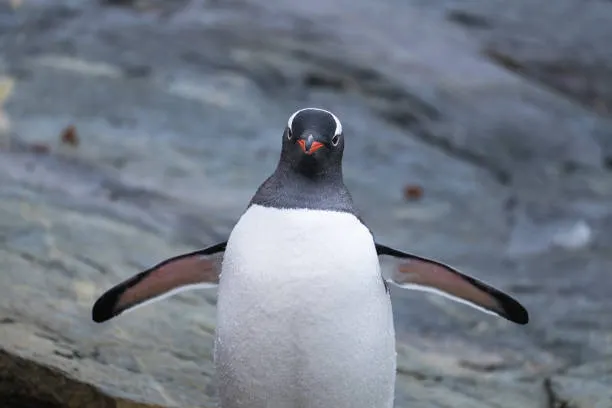
week2 assignment questions:
training completed!
does scaling make a difference?
see below for unscaled implementation

Learned Weights (w[0]=bias, w[1:]=features):
[  -0.6   -29.71  -21.02  -78.1  -325.  ]

Final Classification Accuracy: 64.26%


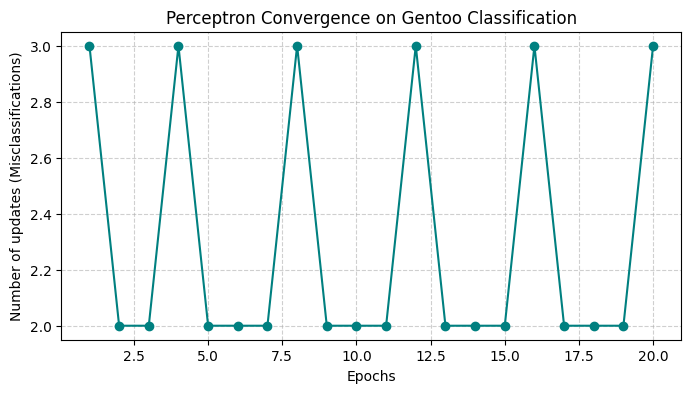

In [ ]:
# 1. Load dataset
penguins = pd.read_csv('../data/penguins.csv')

# 2. Define 0/1 column indicating Gentoo
penguins['isgentoo'] = (penguins['species'] == 'Gentoo').astype(int)

# 3. Predictor columns and target
predictor_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Clean missing values across predictor and target columns
clean_df = penguins.dropna(subset=predictor_cols + ['isgentoo'])

# Strip off unused columns to keep only predictors and target
data = clean_df[predictor_cols + ['isgentoo']]

X = data[predictor_cols].values
y = data['isgentoo'].values

# Standardize feature predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Train the Perceptron function
yhat, w, errors_per_epoch = fit_perceptron(X, y, eta=0.1, iter=20)

# 5. Compute performance stats
accuracy = np.mean(yhat == y) * 100

print(f"Learned Weights (w[0]=bias, w[1:]=features):\n{w}")
print(f"\nFinal Classification Accuracy: {accuracy:.2f}%")

# 6. Plot Updates vs Epochs
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(errors_per_epoch) + 1), errors_per_epoch, marker='o', color='teal')
plt.xlabel('Epochs')
plt.ylabel('Number of updates (Misclassifications)')
plt.title('Perceptron Convergence on Gentoo Classification')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

wow, it leads to overfitting.
different learning rates below

Learned Weights (w[0]=bias, w[1:]=features):
[-0.0003      0.00016076 -0.00017319  0.00017079  0.00012701]

Final Classification Accuracy: 100.00%


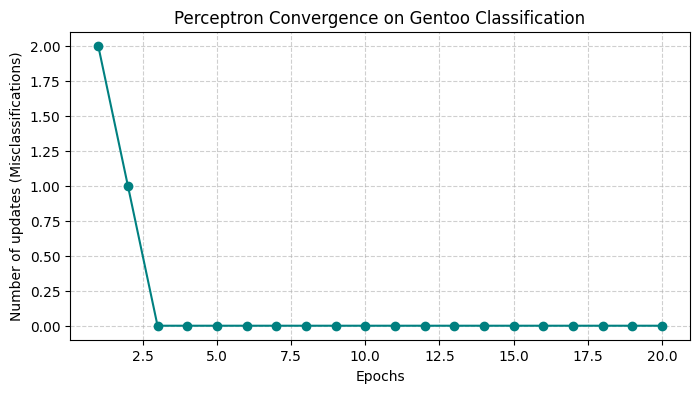

In [ ]:
# 1. Load dataset
penguins = pd.read_csv('../data/penguins.csv')

# 2. Define 0/1 column indicating Gentoo
penguins['isgentoo'] = (penguins['species'] == 'Gentoo').astype(int)

# 3. Predictor columns and target
predictor_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Clean missing values across predictor and target columns
clean_df = penguins.dropna(subset=predictor_cols + ['isgentoo'])

# Strip off unused columns to keep only predictors and target
data = clean_df[predictor_cols + ['isgentoo']]

X = data[predictor_cols].values
y = data['isgentoo'].values

# Standardize feature predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Train the Perceptron function
yhat, w, errors_per_epoch = fit_perceptron(X_scaled, y, eta=.0001, iter=20)

# 5. Compute performance stats
accuracy = np.mean(yhat == y) * 100

print(f"Learned Weights (w[0]=bias, w[1:]=features):\n{w}")
print(f"\nFinal Classification Accuracy: {accuracy:.2f}%")

# 6. Plot Updates vs Epochs
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(errors_per_epoch) + 1), errors_per_epoch, marker='o', color='teal')
plt.xlabel('Epochs')
plt.ylabel('Number of updates (Misclassifications)')
plt.title('Perceptron Convergence on Gentoo Classification')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

I only changed the eta between 1.0 to 0.000001 and it did not seem to affect the convergence

Perceptron on different species


Adelie
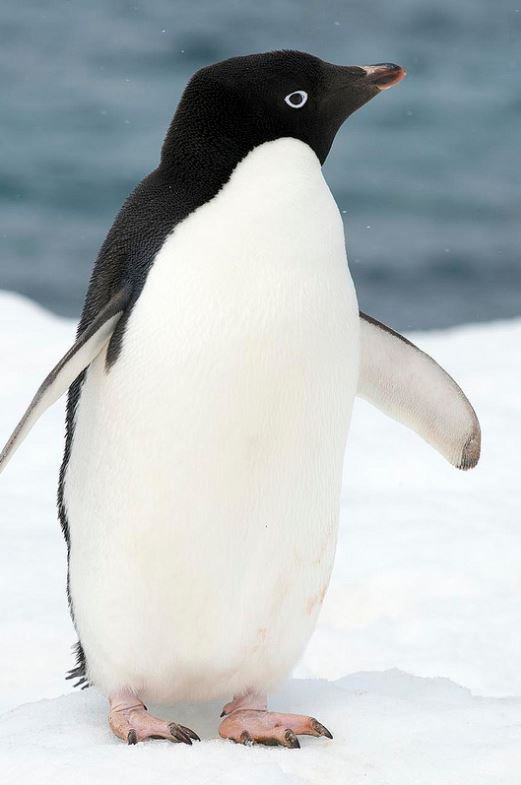
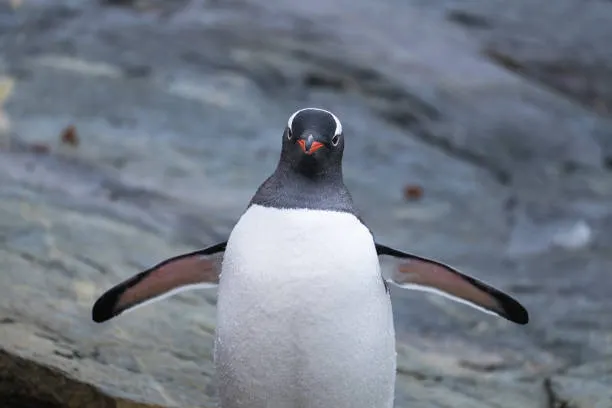

Learned Weights (w[0]=bias, w[1:]=features):
[-3.00000000e-04 -8.84938296e-04  5.23557850e-04  6.43744127e-06
  1.02134973e-04]

Final Classification Accuracy: 99.40%


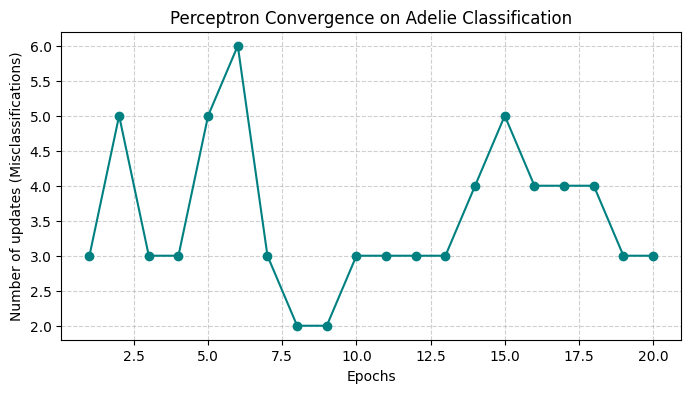

In [ ]:
# 1. Load dataset
penguins = pd.read_csv('../data/penguins.csv')

# 2. Define 0/1 column indicating Adelie
penguins['isadelie'] = (penguins['species'] == 'Adelie').astype(int)

# 3. Predictor columns and target
predictor_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Clean missing values across predictor and target columns
clean_df = penguins.dropna(subset=predictor_cols + ['isadelie'])

# Strip off unused columns to keep only predictors and target
data = clean_df[predictor_cols + ['isadelie']]

X = data[predictor_cols].values
y = data['isadelie'].values

# Standardize feature predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Train the Perceptron function
yhat, w, errors_per_epoch = fit_perceptron(X_scaled, y, eta=.0001, iter=20)

# 5. Compute performance stats
accuracy = np.mean(yhat == y) * 100

print(f"Learned Weights (w[0]=bias, w[1:]=features):\n{w}")
print(f"\nFinal Classification Accuracy: {accuracy:.2f}%")

# 6. Plot Updates vs Epochs
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(errors_per_epoch) + 1), errors_per_epoch, marker='o', color='teal')
plt.xlabel('Epochs')
plt.ylabel('Number of updates (Misclassifications)')
plt.title('Perceptron Convergence on Adelie Classification')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Chinstrap 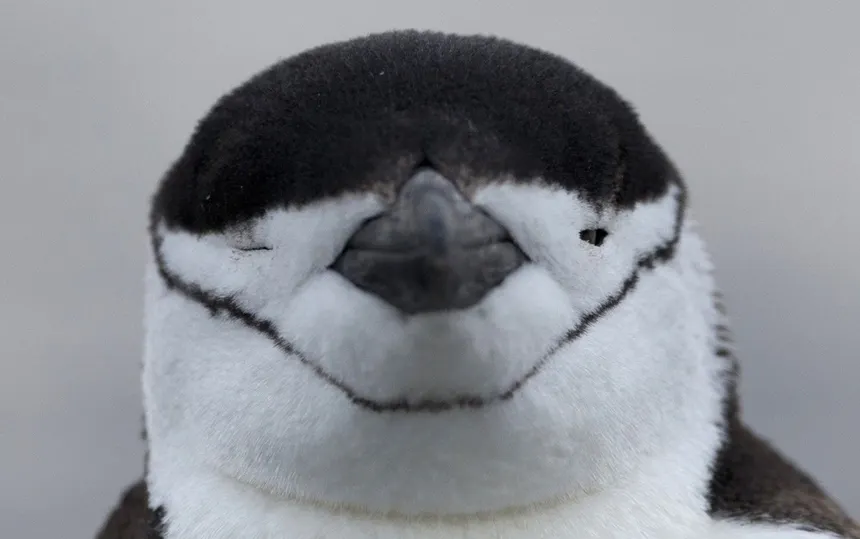

Learned Weights (w[0]=bias, w[1:]=features):
[-0.6         1.02659574  0.29950973 -0.44444095 -0.75965338]

Final Classification Accuracy: 94.29%


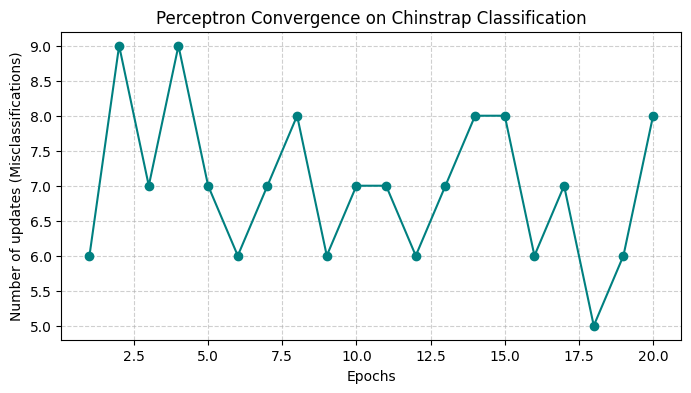

In [ ]:
# 1. Load dataset
penguins = pd.read_csv('../data/penguins.csv')

# 2. Define 0/1 column indicating Chinstrap
penguins['ischinstrap'] = (penguins['species'] == 'Chinstrap').astype(int)

# 3. Predictor columns and target
predictor_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Clean missing values across predictor and target columns
clean_df = penguins.dropna(subset=predictor_cols + ['ischinstrap'])

# Strip off unused columns to keep only predictors and target
data = clean_df[predictor_cols + ['ischinstrap']]

X = data[predictor_cols].values
y = data['ischinstrap'].values

# Standardize feature predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Train the Perceptron function
yhat, w, errors_per_epoch = fit_perceptron(X_scaled, y, eta=.1, iter=20)

# 5. Compute performance stats
accuracy = np.mean(yhat == y) * 100

print(f"Learned Weights (w[0]=bias, w[1:]=features):\n{w}")
print(f"\nFinal Classification Accuracy: {accuracy:.2f}%")

# 6. Plot Updates vs Epochs
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(errors_per_epoch) + 1), errors_per_epoch, marker='o', color='teal')
plt.xlabel('Epochs')
plt.ylabel('Number of updates (Misclassifications)')
plt.title('Perceptron Convergence on Chinstrap Classification')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

unscaled

Learned Weights (w[0]=bias, w[1:]=features):
[2.000e-01 2.585e+01 2.510e+00 6.220e+01 2.900e+02]

Final Classification Accuracy: 20.42%


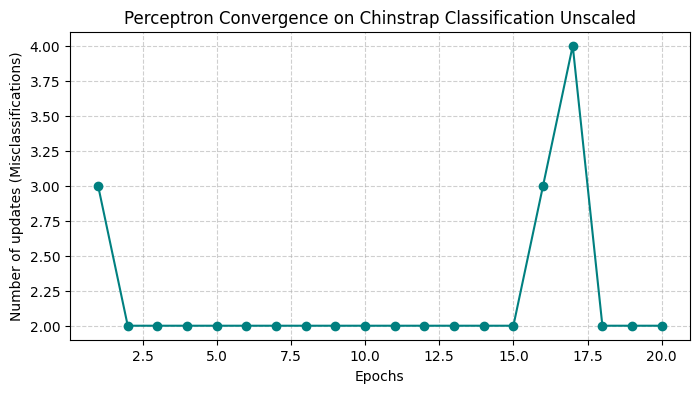

In [ ]:
# 1. Load dataset
penguins = pd.read_csv('../data/penguins.csv')

# 2. Define 0/1 column indicating Chinstrap
penguins['ischinstrap'] = (penguins['species'] == 'Chinstrap').astype(int)

# 3. Predictor columns and target
predictor_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Clean missing values across predictor and target columns
clean_df = penguins.dropna(subset=predictor_cols + ['ischinstrap'])

# Strip off unused columns to keep only predictors and target
data = clean_df[predictor_cols + ['ischinstrap']]

X = data[predictor_cols].values
y = data['ischinstrap'].values

# Standardize feature predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Train the Perceptron function
yhat, w, errors_per_epoch = fit_perceptron(X, y, eta=.1, iter=20)

# 5. Compute performance stats
accuracy = np.mean(yhat == y) * 100

print(f"Learned Weights (w[0]=bias, w[1:]=features):\n{w}")
print(f"\nFinal Classification Accuracy: {accuracy:.2f}%")

# 6. Plot Updates vs Epochs
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(errors_per_epoch) + 1), errors_per_epoch, marker='o', color='teal')
plt.xlabel('Epochs')
plt.ylabel('Number of updates (Misclassifications)')
plt.title('Perceptron Convergence on Chinstrap Classification Unscaled')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Learned Weights (w[0]=bias, w[1:]=features):
[ 3.000e-04 -2.110e-03  1.609e-02 -3.700e-03 -3.550e-01]

Final Classification Accuracy: 56.16%


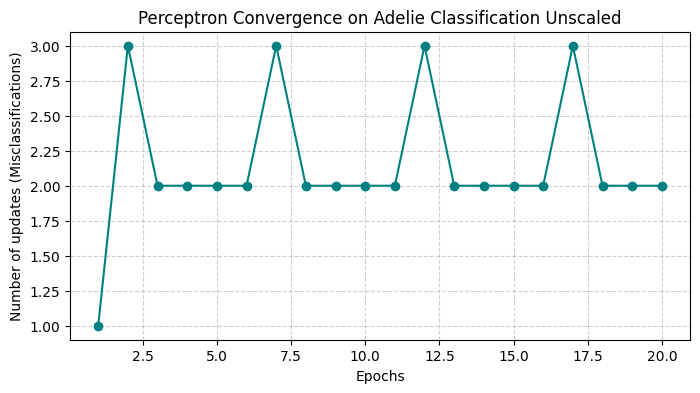

In [ ]:
# 1. Load dataset
penguins = pd.read_csv('../data/penguins.csv')

# 2. Define 0/1 column indicating Adelie
penguins['isadelie'] = (penguins['species'] == 'Adelie').astype(int)

# 3. Predictor columns and target
predictor_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Clean missing values across predictor and target columns
clean_df = penguins.dropna(subset=predictor_cols + ['isadelie'])

# Strip off unused columns to keep only predictors and target
data = clean_df[predictor_cols + ['isadelie']]

X = data[predictor_cols].values
y = data['isadelie'].values

# Standardize feature predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Train the Perceptron function
yhat, w, errors_per_epoch = fit_perceptron(X, y, eta=.0001, iter=20)

# 5. Compute performance stats
accuracy = np.mean(yhat == y) * 100

print(f"Learned Weights (w[0]=bias, w[1:]=features):\n{w}")
print(f"\nFinal Classification Accuracy: {accuracy:.2f}%")

# 6. Plot Updates vs Epochs
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(errors_per_epoch) + 1), errors_per_epoch, marker='o', color='teal')
plt.xlabel('Epochs')
plt.ylabel('Number of updates (Misclassifications)')
plt.title('Perceptron Convergence on Adelie Classification Unscaled')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

make moons 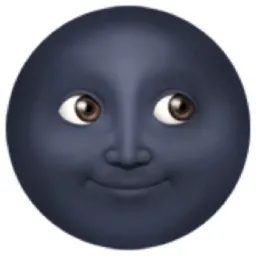

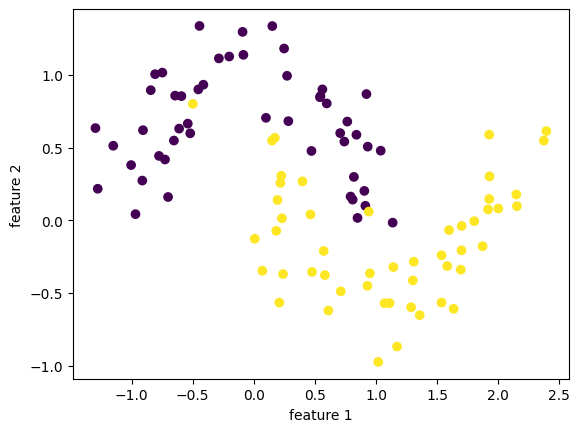

In [ ]:
from sklearn import datasets
X_moon, y_moon = datasets.make_moons(n_samples=100, noise=0.2)
plt.scatter(X_moon[:, 0], X_moon[:, 1], c=y_moon)
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.show()

Learned Weights (w[0]=bias, w[1:]=features):
[ 1.00000000e-04  4.31592357e-05 -2.10972294e-04]

Final Classification Accuracy: 82.00%


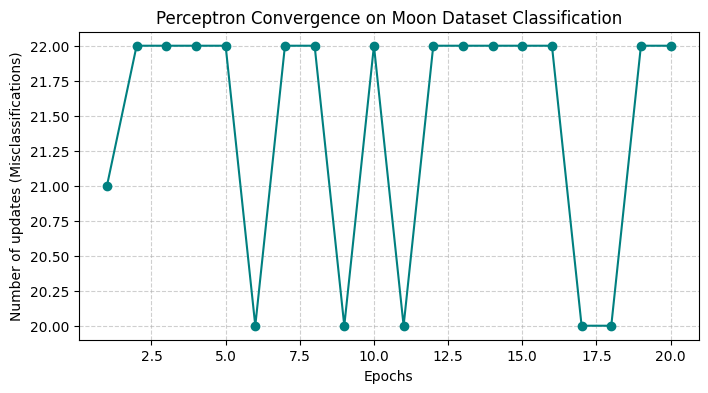

In [ ]:
X = X_moon
y = y_moon

# 3. Standardize feature predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Train the Perceptron function
yhat, w, errors_per_epoch = fit_perceptron(X_scaled, y, eta=0.0001, iter=20)

# 5. Compute performance stats
accuracy = np.mean(yhat == y) * 100

print(f"Learned Weights (w[0]=bias, w[1:]=features):\n{w}")
print(f"\nFinal Classification Accuracy: {accuracy:.2f}%")

# 6. Plot Updates vs Epochs
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(errors_per_epoch) + 1), errors_per_epoch, marker='o', color='teal')
plt.xlabel('Epochs')
plt.ylabel('Number of updates (Misclassifications)')
plt.title('Perceptron Convergence on Moon Dataset Classification')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

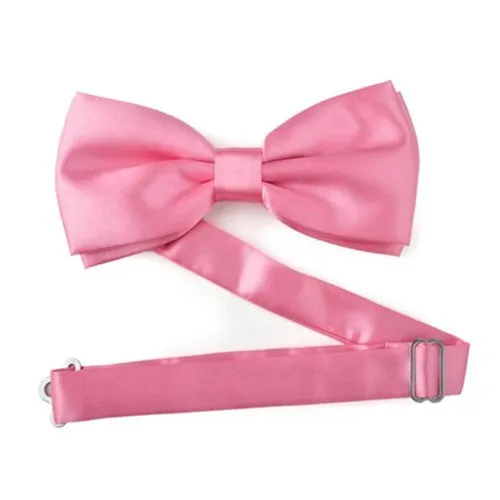  Breast Cancer

Learned Weights (w[0]=bias, w[1:]=features):
[-0.04        0.01827395  0.0643634   0.0224553  -0.01120132 -0.03351812
  0.11014674 -0.09721348 -0.07108652  0.03795063  0.0173521  -0.1527458
  0.03125232 -0.05734317 -0.15898472 -0.03066486  0.00486885  0.08780804
 -0.0433464  -0.00124082  0.04123929 -0.0988472  -0.15572932 -0.06879491
 -0.11469796 -0.01573517  0.01374763 -0.09227394 -0.10153782 -0.09009383
 -0.02486327]

Final Classification Accuracy: 98.59%


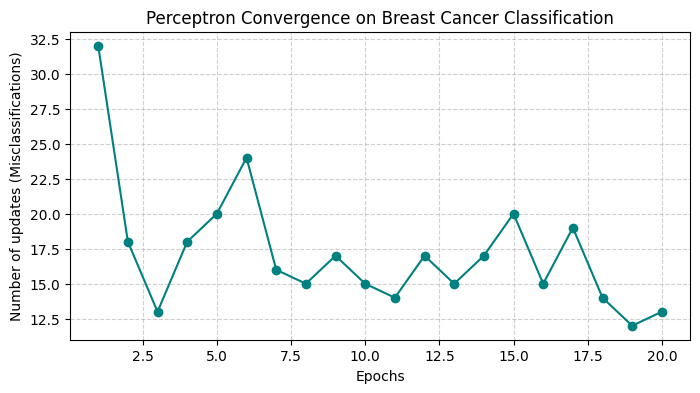

In [105]:
import numpy as np
import sklearn.datasets
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
scaler = StandardScaler()

cancer = sklearn.datasets.load_breast_cancer()
cancer
X = cancer.data
y = cancer.target
X_scaled = scaler.fit_transform(X)

# 3. Fit a Perceptron model
ppn = Perceptron(max_iter=1000, eta0=0.01, random_state=42)
ppn.fit(X_scaled, y)

yhat, w, errors_per_epoch = fit_perceptron(X_scaled, y, eta=0.01, iter=20)

accuracy = np.mean(yhat == y) * 100

print(f"Learned Weights (w[0]=bias, w[1:]=features):\n{w}")
print(f"\nFinal Classification Accuracy: {accuracy:.2f}%")

# 6. Plot Updates vs Epochs
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(errors_per_epoch) + 1), errors_per_epoch, marker='o', color='teal')
plt.xlabel('Epochs')
plt.ylabel('Number of updates (Misclassifications)')
plt.title('Perceptron Convergence on Breast Cancer Classification')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Overall: Never truly converges. Low error. High accuracy. 
Scale Data: scaling depends on what kind of data is available but generally, yes I would recommend scaling.
Train/Test splits are recommended so that models do not memorize the data.